In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

# Data

In [2]:
features_df = pd.read_parquet(r"..\data\features\features.parquet", engine="pyarrow")

# Data preprocessing

In [3]:
# Mobile mean with a window of one hour
hours = 1
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_mobile_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_mobile_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_mobile_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()
features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

In [6]:
# Select one month of data
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]

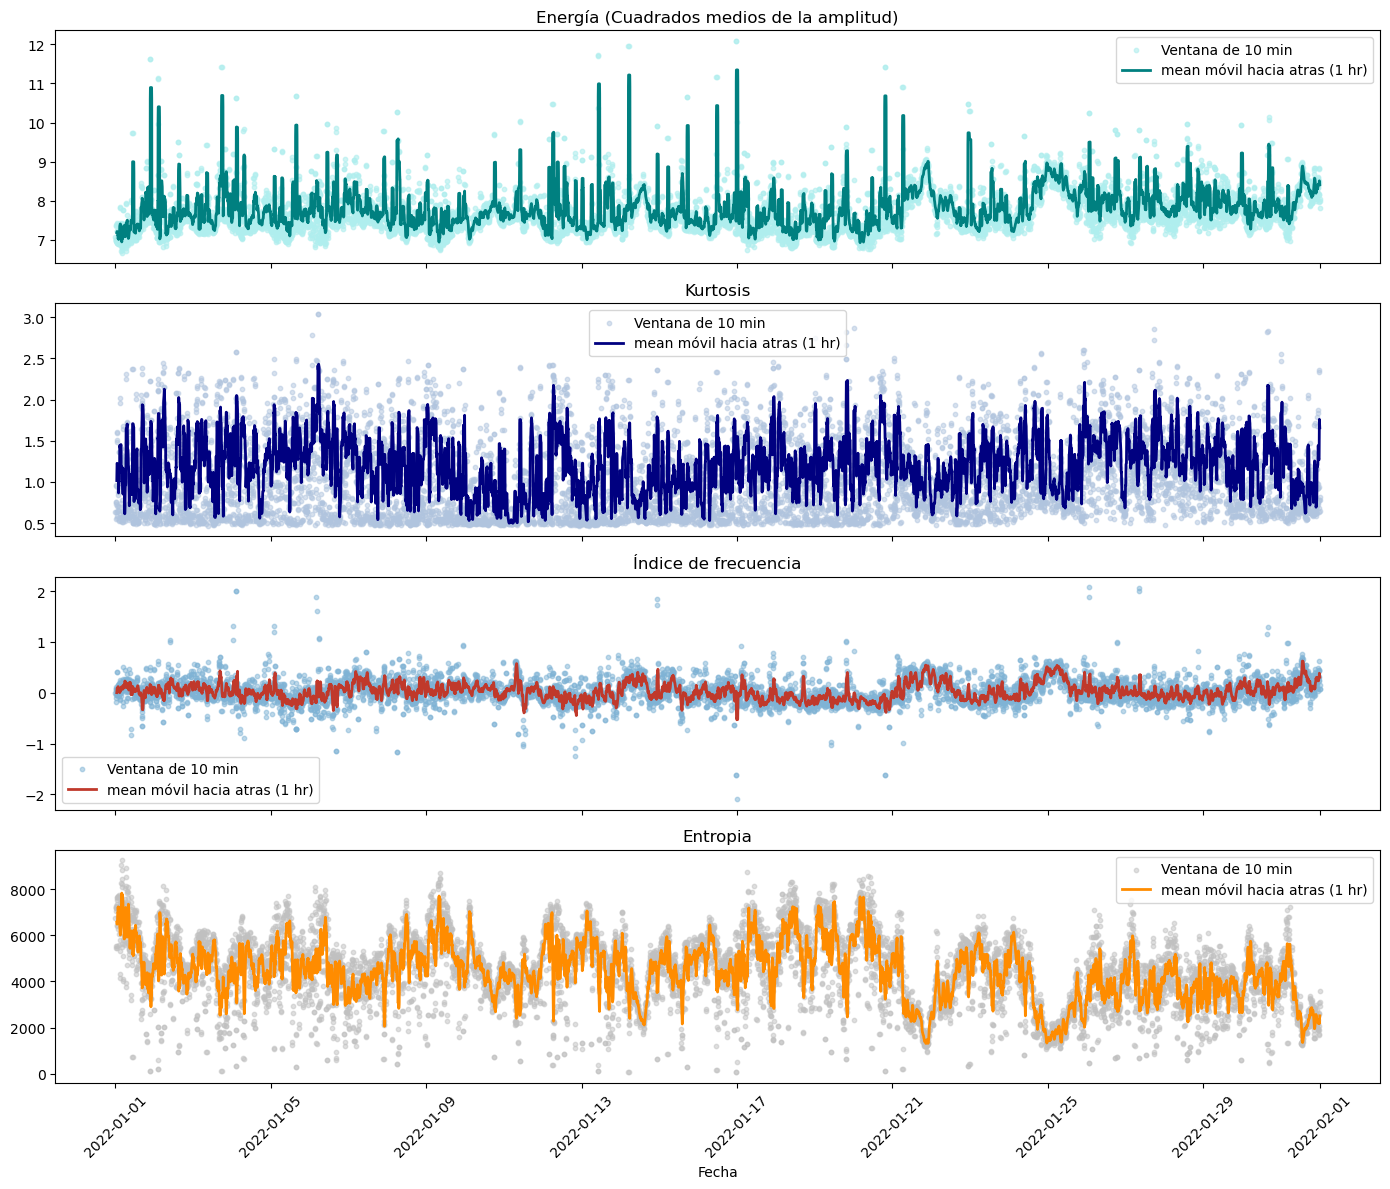

In [ ]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df_1_month['timestamp'], features_df_1_month['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df_1_month['timestamp'], features_df_1_month['energy_mobile_mean'], color='teal', linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df_1_month['timestamp'], features_df_1_month['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df_1_month['timestamp'], features_df_1_month['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df_1_month['timestamp'], features_df_1_month['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df_1_month['timestamp'], features_df_1_month['frequency_index_mobile_mean'], color='#C0392B', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df_1_month['timestamp'], features_df_1_month['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df_1_month['timestamp'], features_df_1_month['entropy_mobile_mean'], color='darkorange', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

# Autoencoder Model

In [4]:
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [7]:
# Extract the relevant features for the autoencoder
feature_columns = ['energy_mobile_mean', 'kurtosis_mobile_mean', 'frequency_index_mobile_mean', 'entropy_mobile_mean']

# Remove NaN values
data = features_df_1_month[feature_columns].dropna().values

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Split into train and test sets
X_train, X_test = train_test_split(data_scaled, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {data_scaled.shape[1]}")

Training set shape: (7106, 4)
Test set shape: (1777, 4)
Number of features: 4


In [ ]:
# Build the Autoencoder Model
input_dim = data_scaled.shape[1]
latent_dim = 4  # Bottleneck layer dimension #También probar con 8 #Agregar una capa adicional al encoder y decoder

# 1. Construcción del ENCODER
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(8, activation='relu')(encoder_input)  # Capa intermedia
latent_space = layers.Dense(latent_dim, activation='relu')(x)
encoder = Model(encoder_input, latent_space, name="encoder")

# 2. Construcción del DECODER
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(8, activation='relu')(decoder_input)
output_data = layers.Dense(input_dim, activation='sigmoid')(x)  # Sigmoid si los datos están normalizados 0-1
decoder = Model(decoder_input, output_data, name="decoder")

# 3. Construcción del AUTOENCODER (Uniendo ambos)
autoencoder_input = layers.Input(shape=(input_dim,))
encoded_repr = encoder(autoencoder_input)
decoded_repr = decoder(encoded_repr)
autoencoder = Model(autoencoder_input, decoded_repr, name="autoencoder")

# 4. Compilación
autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder Architecture:")
autoencoder.summary()

Autoencoder Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the Autoencoder
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8871 - val_loss: 0.8372
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7178 - val_loss: 0.7167
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6473 - val_loss: 0.6648
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6093 - val_loss: 0.6280
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5823 - val_loss: 0.6013
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5626 - val_loss: 0.5814
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5477 - val_loss: 0.5657
Epoch 8/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5365 - val_loss: 0.5546
Epoch 9/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5277 - val_loss: 0.5441
Epoch 10/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5206 - val_loss: 0.5358
Epoch 11/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5147 - val_loss: 0.5299
Epoch 12/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


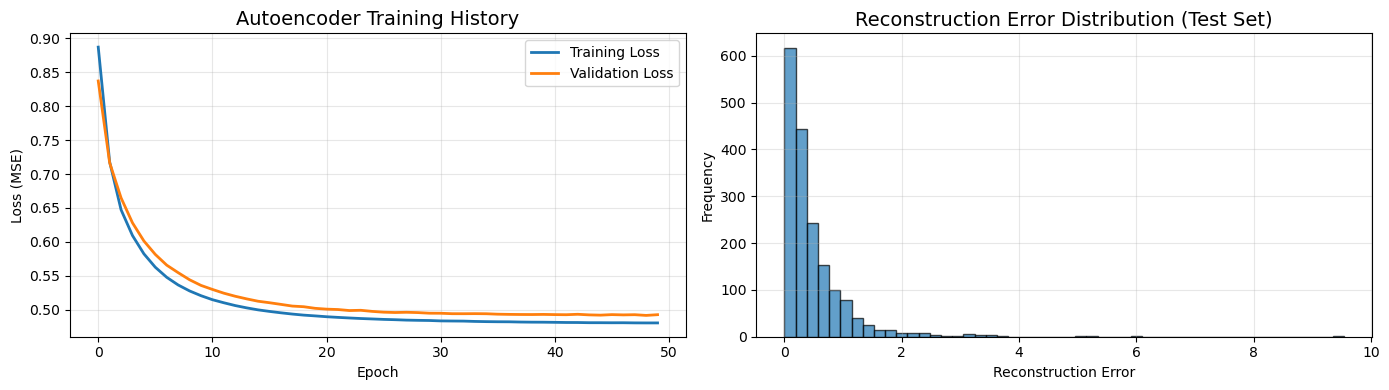


Test Set MSE Loss: 0.000000
Reconstruction Error - Mean: 0.480481, Std: 0.628777


In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Autoencoder Training History', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Get predictions on test set
X_test_pred = autoencoder.predict(X_test)
test_loss = autoencoder.evaluate(X_test, X_test_pred, verbose=0)
reconstruction_error = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

axes[1].hist(reconstruction_error, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Reconstruction Error Distribution (Test Set)', fontsize=14)
axes[1].set_xlabel('Reconstruction Error')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTest Set MSE Loss: {test_loss:.6f}")
print(f"Reconstruction Error - Mean: {reconstruction_error.mean():.6f}, Std: {reconstruction_error.std():.6f}")

In [13]:
features_df_forecast = features_df[(features_df['timestamp']<"2023-06-01") & (features_df['timestamp']>="2022-02-01")]

# Outlier Detection using Autoencoder

In [14]:
# Prepare forecast data with the same features
forecast_data = features_df_forecast[feature_columns].dropna().values
forecast_data_scaled = scaler.transform(forecast_data)

# Get predictions on forecast data
forecast_pred = autoencoder.predict(forecast_data_scaled)

# Calculate reconstruction error for forecast data
forecast_reconstruction_error = np.mean(np.power(forecast_data_scaled - forecast_pred, 2), axis=1)

print(f"Forecast data shape: {forecast_data_scaled.shape}")
print(f"Reconstruction Error - Mean: {forecast_reconstruction_error.mean():.6f}")
print(f"Reconstruction Error - Std: {forecast_reconstruction_error.std():.6f}")
print(f"Reconstruction Error - Min: {forecast_reconstruction_error.min():.6f}")
print(f"Reconstruction Error - Max: {forecast_reconstruction_error.max():.6f}")

4240/4240 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Forecast data shape: (135671, 4)
Reconstruction Error - Mean: 2.060678
Reconstruction Error - Std: 2.744515
Reconstruction Error - Min: 0.000214
Reconstruction Error - Max: 31.866684


In [22]:
# Create dataframe with forecast predictions and dates
# Get the dates corresponding to non-NaN forecast data
forecast_dates = features_df_forecast[feature_columns].dropna().index

# Inverse transform the predictions to original scale
forecast_pred_unscaled = scaler.inverse_transform(forecast_pred)

# Create dataframe from unscaled forecast predictions
forecast_pred_df = pd.DataFrame(
    forecast_pred_unscaled,
    columns=feature_columns,
    index=forecast_dates
)

# Add the date column from features_df_forecast
forecast_pred_df['timestamp'] = features_df_forecast.loc[forecast_dates, 'timestamp'].values

print(f"Forecast predictions dataframe shape: {forecast_pred_df.shape}")
print(f"\nFirst 5 rows:")
print(forecast_pred_df.head())
print(f"\nDataframe info:")
print(forecast_pred_df.info())

Forecast predictions dataframe shape: (135671, 5)

First 5 rows:
      energy_mobile_mean  kurtosis_mobile_mean  frequency_index_mobile_mean  \
8897            8.768014              1.489930                     0.181530   
8898            8.727589              1.478134                     0.174684   
8899            8.682462              1.464966                     0.167042   
8900            8.655374              1.457062                     0.162455   
8901            8.647575              1.454786                     0.161135   

      entropy_mobile_mean           timestamp  
8897          2611.907471 2022-02-01 00:05:00  
8898          2695.806396 2022-02-01 00:10:00  
8899          2789.464844 2022-02-01 00:15:00  
8900          2845.683105 2022-02-01 00:20:00  
8901          2861.868164 2022-02-01 00:25:00  

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
Index: 135671 entries, 8897 to 148091
Data columns (total 5 columns):
 #   Column                       Non-Null Coun

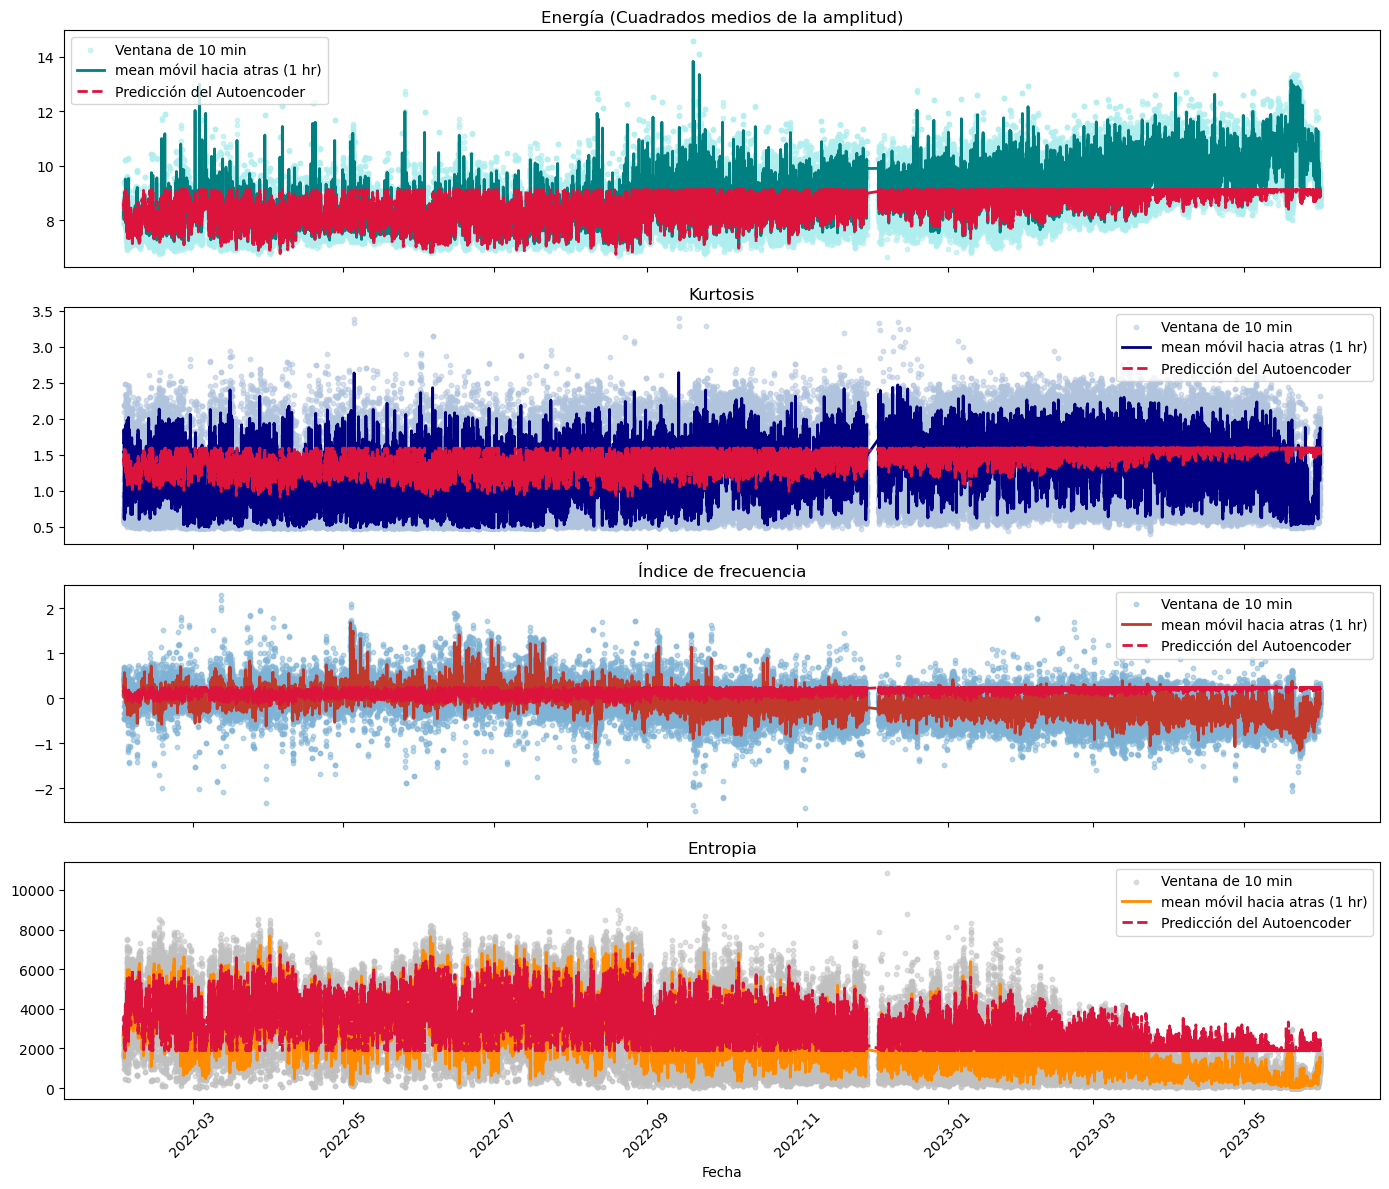

In [23]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
# Energy plot
axes[0].scatter(features_df_forecast['timestamp'], features_df_forecast['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df_forecast['timestamp'], features_df_forecast['energy_mobile_mean'], color='teal', linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[0].plot(forecast_pred_df['timestamp'], forecast_pred_df['energy_mobile_mean'], color='crimson', linewidth=2, linestyle='--', label='Predicción del Autoencoder')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

# Kurtosis plot
axes[1].scatter(features_df_forecast['timestamp'], features_df_forecast['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df_forecast['timestamp'], features_df_forecast['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[1].plot(forecast_pred_df['timestamp'], forecast_pred_df['kurtosis_mobile_mean'], color='crimson', linewidth=2, linestyle='--', label='Predicción del Autoencoder')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

# Frequency index plot
axes[2].scatter(features_df_forecast['timestamp'], features_df_forecast['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df_forecast['timestamp'], features_df_forecast['frequency_index_mobile_mean'], color='#C0392B', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[2].plot(forecast_pred_df['timestamp'], forecast_pred_df['frequency_index_mobile_mean'], color='crimson', linewidth=2, linestyle='--', label='Predicción del Autoencoder')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

# Entropy plot
axes[3].scatter(features_df_forecast['timestamp'], features_df_forecast['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df_forecast['timestamp'], features_df_forecast['entropy_mobile_mean'], color='darkorange', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[3].plot(forecast_pred_df['timestamp'], forecast_pred_df['entropy_mobile_mean'], color='crimson', linewidth=2, linestyle='--', label='Predicción del Autoencoder')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()